### Hypotheses:

> Students who drink alcohol more frequently during the week are associated with worse grades.

> Students who have family support at home are associated with better final grades

> Better previous grades will be associated with better final grades.

> Students who have more free time are associated with better final grades, but this will vary by sex.

> Students with larger families can be identified by their final grade in portuguese



# Factorial ANOVA

> Students who have more free time are associated with better final grades, but this will vary by sex.

Free time is the amount of free time a student has after school. It is represented by a categorical variable *freetime* which has values from 1 to 6, with 1 being "very low" amounts of free time, and 5 being "very high".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# new packages
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.anova as smsa
import patsy.contrasts as contr

# utilities written for the module
%run utils.py

In [2]:
df = pd.read_csv("prepared_dataset.csv")

# Drop rows where 'pG3' is 0
#df = df[df['pG3'] != 0]

df

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
0,0,GP,F,15,R,GT3,T,1,1,at_home,...,3,1,2,1,1,1,4,13,13,13
1,1,GP,F,15,R,GT3,T,1,1,other,...,3,3,4,2,4,5,2,13,11,11
2,2,GP,F,15,R,GT3,T,2,2,at_home,...,4,3,1,1,1,2,8,14,13,12
3,3,GP,F,15,R,GT3,T,2,4,services,...,4,3,2,1,1,5,2,10,11,10
4,4,GP,F,15,R,GT3,T,3,3,services,...,4,2,1,2,3,3,2,13,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,377,MS,M,18,U,LE3,T,1,3,at_home,...,4,3,3,2,3,3,0,9,10,9
366,378,MS,M,18,U,LE3,T,4,4,teacher,...,4,2,2,2,2,5,0,15,16,16
367,379,MS,M,19,R,GT3,T,1,1,other,...,4,4,4,3,3,5,4,8,9,10
368,380,MS,M,19,R,GT3,T,1,1,other,...,5,4,4,3,3,2,8,10,9,11


Assumptions for ANOVA:

- data in the groups is independent
- if group sizes are different 
    - group populations must be homoskedastic
    - distribution of each group is normal, or distribution of residuals is normal.


In [3]:
print("Sex:")
print( df.sex.value_counts())
print()
print("freetime:")
print( df.freetime.value_counts())

Sex:
F    195
M    175
Name: sex, dtype: int64

freetime:
3    152
4    105
2     60
5     36
1     17
Name: freetime, dtype: int64


freetime category counts
3    152
4    105
2     60
5     36
1     17
Name: freetime, dtype: int64
freetime categories [1 3 2 4 5]

Sex category counts
F    195
M    175
Name: sex, dtype: int64
sex categories ['F' 'M']


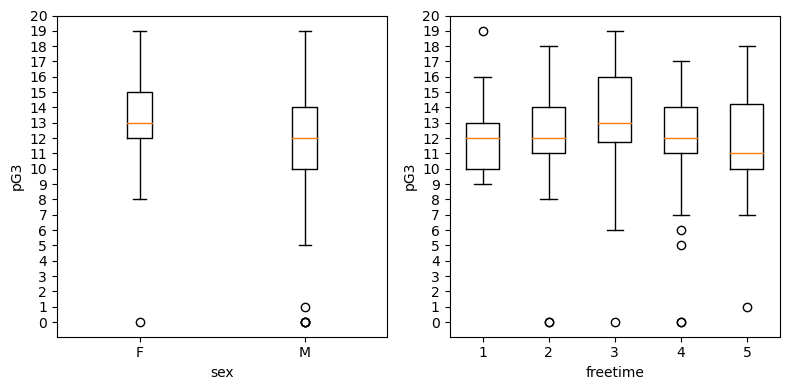

In [4]:
freetime_cats = df.freetime.unique()
freetime_cat_counts= df.freetime.value_counts()

sex_categories = df.sex.unique()# = df.sex.unique()
sex_counts = df.sex.value_counts()

print("freetime category counts")
print( freetime_cat_counts)
print("freetime categories", freetime_cats)
print()
print("Sex category counts")
print(sex_counts)
print("sex categories", sex_categories)


plt.figure(figsize=(8, 4), tight_layout = True)
plt.subplot(121)
plt.boxplot(list(df.pG3[df.sex == c] for c in df.sex.unique() ))
plt.xlabel("sex")
plt.ylabel("pG3")
plt.yticks(np.arange(0, 21, 1))
plt.xticks(np.arange(len(df.sex.unique()))+1,df.sex.unique())

plt.subplot(122)
plt.boxplot(list(df.pG3[df.freetime == cat] for cat in freetime_cats))
plt.xlabel("freetime")
plt.ylabel("pG3")
plt.yticks(np.arange(0, 21, 1))
plt.show()

In [5]:
# Homoskedasticity test
var = "freetime"
ss.bartlett(*[df['pG3'][df[var] == cat] for cat in df[var].unique()])


BartlettResult(statistic=5.998054215551943, pvalue=0.19929363295853372)

The bartlett test results indicate that we failed to reject the null hypothesis that freetime had equal variances. Therefore, the assumption of homoskedasticity is met.

Freetime's category value counts are unbalanced and skewed left.

## Factorial ANOVA

In [6]:
# encode categorical variables
sex_coding = contr.Helmert().code_without_intercept(sex_categories)
freetime_coding = contr.Helmert().code_without_intercept(freetime_cats)
sex_coding, freetime_coding

(ContrastMatrix(array([[-1.],
                       [ 1.]]),
                ['[H.M]']),
 ContrastMatrix(array([[-1., -1., -1., -1.],
                       [ 1., -1., -1., -1.],
                       [ 0.,  2., -1., -1.],
                       [ 0.,  0.,  3., -1.],
                       [ 0.,  0.,  0.,  4.]]),
                ['[H.3]', '[H.2]', '[H.4]', '[H.5]']))

In [7]:
# Factorial ANOVA test

#regression
survey_m = smf.ols("pG3 ~ C(sex, sex_coding, sex_categories) * C(freetime, freetime_coding, freetime_cats)", data=df).fit()
survey_m.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    pG3   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     2.730
Date:                Fri, 22 Dec 2023   Prob (F-statistic):            0.00431
Time:                        05:53:56   Log-Likelihood:                -911.76
No. Observations:                 370   AIC:                             1844.
Df Residuals:                     360   BIC:                             1883.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
============================================================================================================================================================
                                                                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                   12.3889      0.227     54.480      0.000      11.942      12.836
C(sex, sex_coding, sex_categories)[H.M]                                                     -0.4529      0.227     -1.991      0.047      -0.900      -0.006
C(freetime, freetime_coding, freetime_cats)[H.3]                                             0.2730      0.429      0.636      0.525      -0.571       1.117
C(freetime, freetime_coding, freetime_cats)[H.2]                                             0.3985      0.191      2.092      0.037       0.024       0.773
C(freetime, freetime_coding, freetime_cats)[H.4]                                            -0.0373      0.105     -0.354      0.724      -0.244       0.170
C(freetime, freetime_coding, freetime_cats)[H.5]                                            -0.1396      0.126     -1.112      0.267      -0.387       0.107
C(sex, sex_coding, sex_categories)[H.M]:C(freetime, freetime_coding, freetime_cats)[H.3]    -0.0292      0.429     -0.068      0.946      -0.873       0.815
C(sex, sex_coding, sex_categories)[H.M]:C(freetime, freetime_coding, freetime_cats)[H.2]     0.1835      0.191      0.963      0.336      -0.191       0.558
C(sex, sex_coding, sex_categories)[H.M]:C(freetime, freetime_coding, freetime_cats)[H.4]    -0.0650      0.105     -0.618      0.537      -0.272       0.142
C(sex, sex_coding, sex_categories)[H.M]:C(freetime, freetime_coding, freetime_cats)[H.5]     0.1021      0.126      0.813      0.417      -0.145       0.349
==============================================================================
Omnibus:                       77.390   Durbin-Watson:                   1.906
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              244.181
Skew:                          -0.929   Prob(JB):                     9.48e-54
Kurtosis:                       6.519   Cond. No.                         7.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
# analysis of variance
smsa.anova_lm(survey_m, typ=2)

,sum_sq,df,F,PR(>F)
"C(sex, sex_coding, sex_categories)",112.198961,1.0,13.494678,0.000276
"C(freetime, freetime_coding, freetime_cats)",48.624844,4.0,1.462083,0.213206
"C(sex, sex_coding, sex_categories):C(freetime, freetime_coding, freetime_cats)",24.544239,4.0,0.738012,0.566538
Residual,2993.152381,360.0,NaN,NaN


In [9]:
etasq_p = 112/(112+2993.15)
etasq_p

0.03606911099302771

## Report

The Adjusted *$R^2$* value (Adj. *$R^2$* = 0.04) shows 4% of the variance of pG3 explained by the predictors freetime and sex. 

The F score (*F* = 2.73, *p* = 0.00431) shows that the model is significant at 95% 
confidence.

Looking at the coefficients, the intercept value ( coef = 12.3889, *p* < 0.001) is significant at 95% level of confidence. 
This is the baseline (Female and freetime = 1)

**Sex:** 
- M: has a significant main influence on the final grade (coef = -0.4529, *p*=.047)


**Freetime:**
- 2: has a significant main influence on pG3 (coef = 0.3985, *p*= 0.037).
- 3: not significant (coef = 0.2730, *p*= 0.525).
- 4: not significant (coef = -0.0373, *p* = 0.724)
- 5: not significant (coef = -0.1396, *p*=0.267)

The freetime category with the most influence on the final Portuguese grade was 2, representing the second smallest amount (on a scale from 1 to 5) of free time that students had after school. 

**Interactions between Sex and Freetime:**
The effect of "M" Male on the freetime categories at 95% confidence.

- The interaction between M and freetime 2 is not significant (coef = 0.1835, p = 0.336).
- The interaction between M and freetime 3 is not significant (coef = -0.0292, p = 0.946).
- The interaction between M and freetime 4 is not significant (coef = -0.0650, p = 0.537).
- The interaction between M and Freetime 5 is not significant (coef = 0.1021, p = 0.417).

Based on these results being male does not have a significant effect on the final grade depending on the freetime category. However, being male, independently has an effect on the final grade, pG3.
Freetime does have some main effect on pG3, in particular category 2.

#### ANOVA
Effect sizes for $\eta^2$: S = 0.02, M=0.13, L=0.26.
There is a medium effect size ($\eta^2$ = 0.036) for the model. 

A factorial ANOVA was conducted to investigate the effect of sex and free time after school (freetime) on the final grade in Portuguese (pG3). 
The results indicated a significant main effect of sex, F(1, 360) = 7.91, *p* = .0052. 
The effect of free time was not significant, F(4, 360) = 1.462, p = 0.213.
 Additionally, the interaction effect between sex and freetime was not significant,  F(4, 360) = 0.738, p = 0.566538.

This suggests that sex affects pG3, by itself. Free time alone has no significant effect, and no significant interaction between sex and freetime implies that the effect of free time on the final grade does not vary based on sex.

# Assumption testing of residuals

### Normality tests

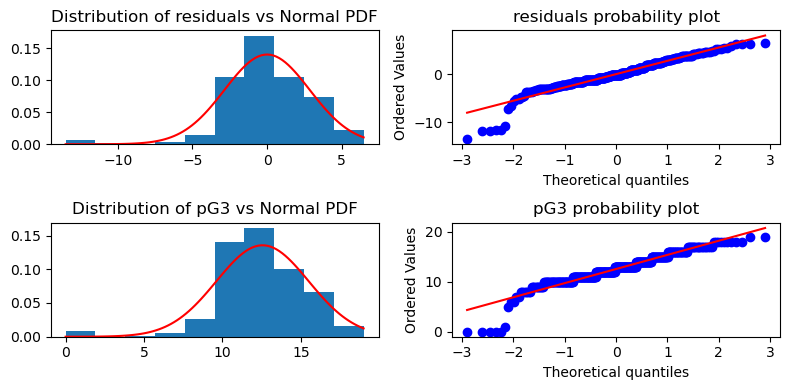

In [10]:
#Normality Tests
plt.figure(figsize=(8, 4), tight_layout = True)

plt.subplot(221)
plot_hist_and_norm_pdf(survey_m.resid, standardize=False, bins=10)

plt.title("Distribution of residuals vs Normal PDF")

plt.subplot(222)
ss.probplot(survey_m.resid, plot=plt)
plt.title("residuals probability plot")

plt.subplot(223)
plot_hist_and_norm_pdf(df["pG3"], standardize=False, bins=10)

plt.title("Distribution of pG3 vs Normal PDF")
plt.subplot(224)
ss.probplot(df.pG3, plot=plt)
plt.title("pG3 probability plot")
plt.show()

In [11]:
print("Skewness:", round(ss.skew(survey_m.resid)/se_skew(len(survey_m.resid)), 3))
print("Kurtosis:", round(ss.kurtosis(survey_m.resid, fisher=True)/se_kurt(len(survey_m.resid)), 3))

Skewness: -7.326
Kurtosis: 13.911


In [12]:
pc_over_2sd(survey_m.resid)

3.5135135135135136

In [13]:
W = ss.shapiro(survey_m.resid)
print(W)

ShapiroResult(statistic=0.9345736503601074, pvalue=1.1247844669548535e-11)


#### Summary of normality tests 

The skewness and kurtosis scores (*Skew* = -7.326, *Kurtosis* = 13.911) suggest that the distribution is skewed to the left and the tails contain outliers.

Over 55% of residual values lie over 2 standard deviations from the mean, suggesting non-normality of the distribution of residuals.

The Shapiro-Wilks goodness of fit test (*W* = 0.93, *p*<0.001) indicates that the residuals are not normally distributed.

The distribution of pG3 is relatively normal, but there are some outliers where students received particularly low grades (e.g. 0), which is unlikely to be a true grade, and more likely indicates that the student was absent. This is interfering with the normality of the residuals, however removing the outliers does not make the distribution of residuals normal either, suggesting that they have little influence on the ANOVA results.

In conclusion, the distribution of residuals can not be considered normal.


### Conclusion:

The factorial ANOVA revealed a significant main effect of sex on final Portuguese grades (pG3), $F(1, 360) = 7.91, p = .0052$, with a medium effect size ($\eta^2 = 0.036$), but no significant effects of free time or interaction between sex and free time, suggesting that sex independently affects Portuguese grades.

However, the assumptions are not met for the normality of the residuals.

